# Multi-Frequency Mapmaking Analysis (with Lake Beam)

Frequency-dependent performance of the `all-nominal-multifreq-lake` beam/site
combination (9 beams, 4 sites, includes lake beam) across the 40–125 MHz band.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

In [2]:
npz_path = Path("results/all-nominal-multifreq-lake.npz")
d = np.load(npz_path)

freqs = d["freqs"]          # full freq array (86,)
sim_freqs = d["sim_freqs"]  # frequencies actually simulated
lmax = int(d["lmax"])
nf = len(sim_freqs)

x_true = d["x_true"]    # (nf, nalm)
x_rec = d["x_rec"]      # (nf, nalm)
std_alm = d["std_alm"]  # (nf, nalm)
Sigma = d["Sigma"]      # (nf, k)
nvec = d["nvec"]        # (nf,)

print(f"lmax = {lmax}, {nf} frequencies: "
      f"{sim_freqs[0]:.0f}–{sim_freqs[-1]:.0f} MHz")
print(f"SVD k = {Sigma.shape[1]}, "
      f"nvec range: {int(nvec.min())}–{int(nvec.max())}")

lmax = 90, 86 frequencies: 40–125 MHz
SVD k = 2000, nvec range: 1463–1465


## 1. Fractional Residual RMS vs Frequency

For each frequency, low-pass filter true and recovered maps
at $\ell \le \ell_{\rm max}^{\rm cut}$, then compute the RMS
of the fractional residual $(\text{true} - \text{recovered}) / \text{true}$.
Plotted for $\ell_{\rm max}^{\rm cut} = 5, 10, 15$.

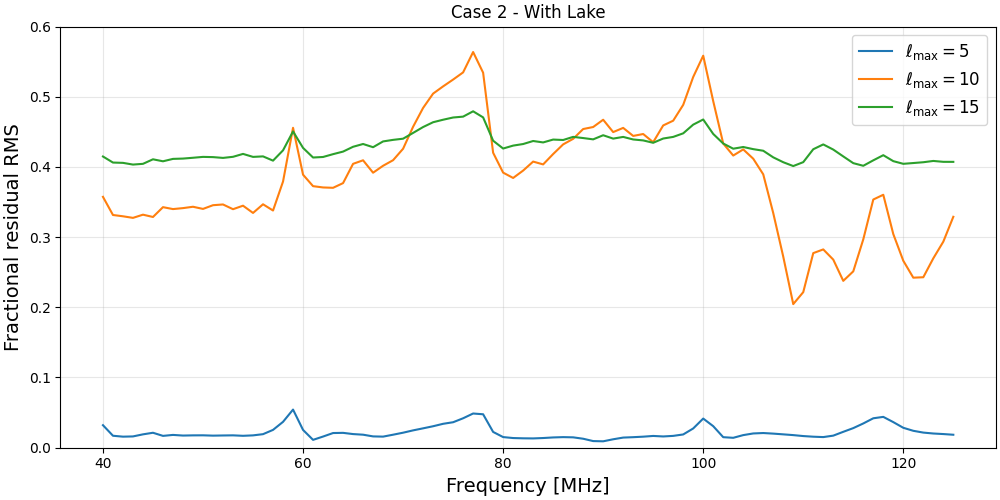

In [7]:
nside = 128
lmax_cuts = [5, 10, 15]

rms_vs_freq = {}  # lmax_cut -> array of RMS values

for lcut in lmax_cuts:
    rms_arr = np.zeros(nf)
    fl = np.zeros(lmax + 1)
    fl[:lcut + 1] = 1.0
    for fi in range(nf):
        true_map = hp.alm2map(hp.almxfl(x_true[fi], fl), nside)
        rec_map = hp.alm2map(hp.almxfl(x_rec[fi], fl), nside)
        frac_res = (true_map - rec_map) / true_map
        rms_arr[fi] = np.std(frac_res)
    rms_vs_freq[lcut] = rms_arr

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for lcut in lmax_cuts:
    ax.plot(sim_freqs, rms_vs_freq[lcut], lw=1.5,
            label=rf"$\ell_{{\rm max}} = {lcut}$")
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Fractional residual RMS", fontsize=14)
#ax.set_title("Fractional Residual RMS vs Frequency (low-pass filtered)")
ax.set_title("Case 2 - With Lake")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.6)
plt.show()

## 2. Select Frequencies for Detailed Analysis

Pick: band start (40 MHz), band end (125 MHz), and the best/worst
residual at $\ell_{\rm max} = 10$.

In [8]:
rms_l10 = rms_vs_freq[10]

idx_best = np.argmin(rms_l10)
idx_worst = np.argmax(rms_l10)
idx_start = 0
idx_end = nf - 1

# Deduplicate (if best/worst coincides with start/end)
select = {}
select[f"{sim_freqs[idx_start]:.0f} MHz (start)"] = idx_start
select[f"{sim_freqs[idx_end]:.0f} MHz (end)"] = idx_end
select[f"{sim_freqs[idx_best]:.0f} MHz (best)"] = idx_best
select[f"{sim_freqs[idx_worst]:.0f} MHz (worst)"] = idx_worst

print("Selected frequencies for detailed analysis:")
for label, fi in select.items():
    print(f"  {label}: index={fi}, "
          f"freq={sim_freqs[fi]:.0f} MHz, "
          f"frac RMS(l<=10) = {rms_l10[fi]:.3e}")

Selected frequencies for detailed analysis:
  40 MHz (start): index=0, freq=40 MHz, frac RMS(l<=10) = 3.573e-01
  125 MHz (end): index=85, freq=125 MHz, frac RMS(l<=10) = 3.288e-01
  109 MHz (best): index=69, freq=109 MHz, frac RMS(l<=10) = 2.044e-01
  77 MHz (worst): index=37, freq=77 MHz, frac RMS(l<=10) = 5.636e-01


## 3. Cumulative Fractional Residual RMS vs $\ell_{\rm max}$

For the selected frequencies, plot how the fractional residual RMS grows
as more multipoles are included.

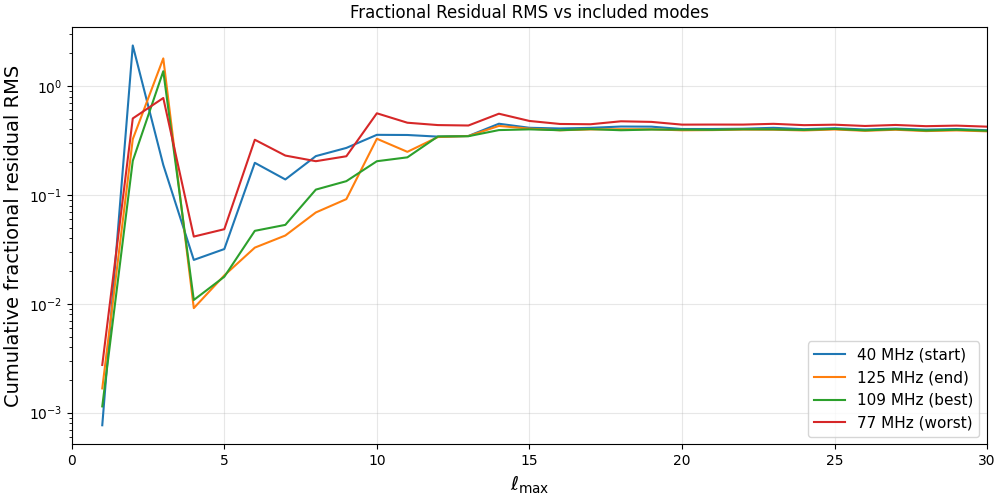

In [9]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
lmax_plot = 30

for label, fi in select.items():
    rms_cum = np.zeros(lmax_plot + 1)
    for lcut in range(1, lmax_plot + 1):
        fl = np.zeros(lmax + 1)
        fl[:lcut + 1] = 1.0
        true_map = hp.alm2map(hp.almxfl(x_true[fi], fl), nside)
        rec_map = hp.alm2map(hp.almxfl(x_rec[fi], fl), nside)
        frac_res = (true_map - rec_map) / true_map
        rms_cum[lcut] = np.std(frac_res)
    ax.semilogy(np.arange(1, lmax_plot + 1), rms_cum[1:],
                lw=1.5, label=label)

ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=14)
ax.set_ylabel("Cumulative fractional residual RMS", fontsize=14)
ax.set_title("Fractional Residual RMS vs included modes")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 30)
plt.show()

## 4. Singular Value Spectrum

Overlay the singular value spectra for the selected frequencies.

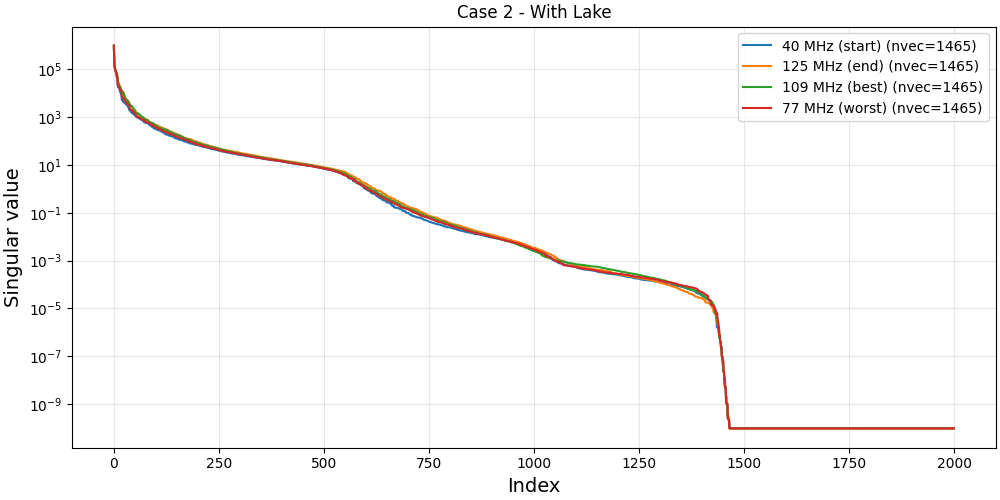

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for label, fi in select.items():
    nv = int(nvec[fi])
    ax.semilogy(Sigma[fi], lw=1.5,
                label=f"{label} (nvec={nv})")

ax.set_xlabel("Index", fontsize=14)
ax.set_ylabel("Singular value", fontsize=14)
ax.set_title("Case 2 - With Lake")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## 5. Map Comparison at $\ell \le 10$

For each selected frequency: true map, recovered map, and
fractional residual $(\text{true} - \text{recovered}) / \text{true}$,
all low-pass filtered at $\ell \le 10$.
Shown in Galactic coordinates.

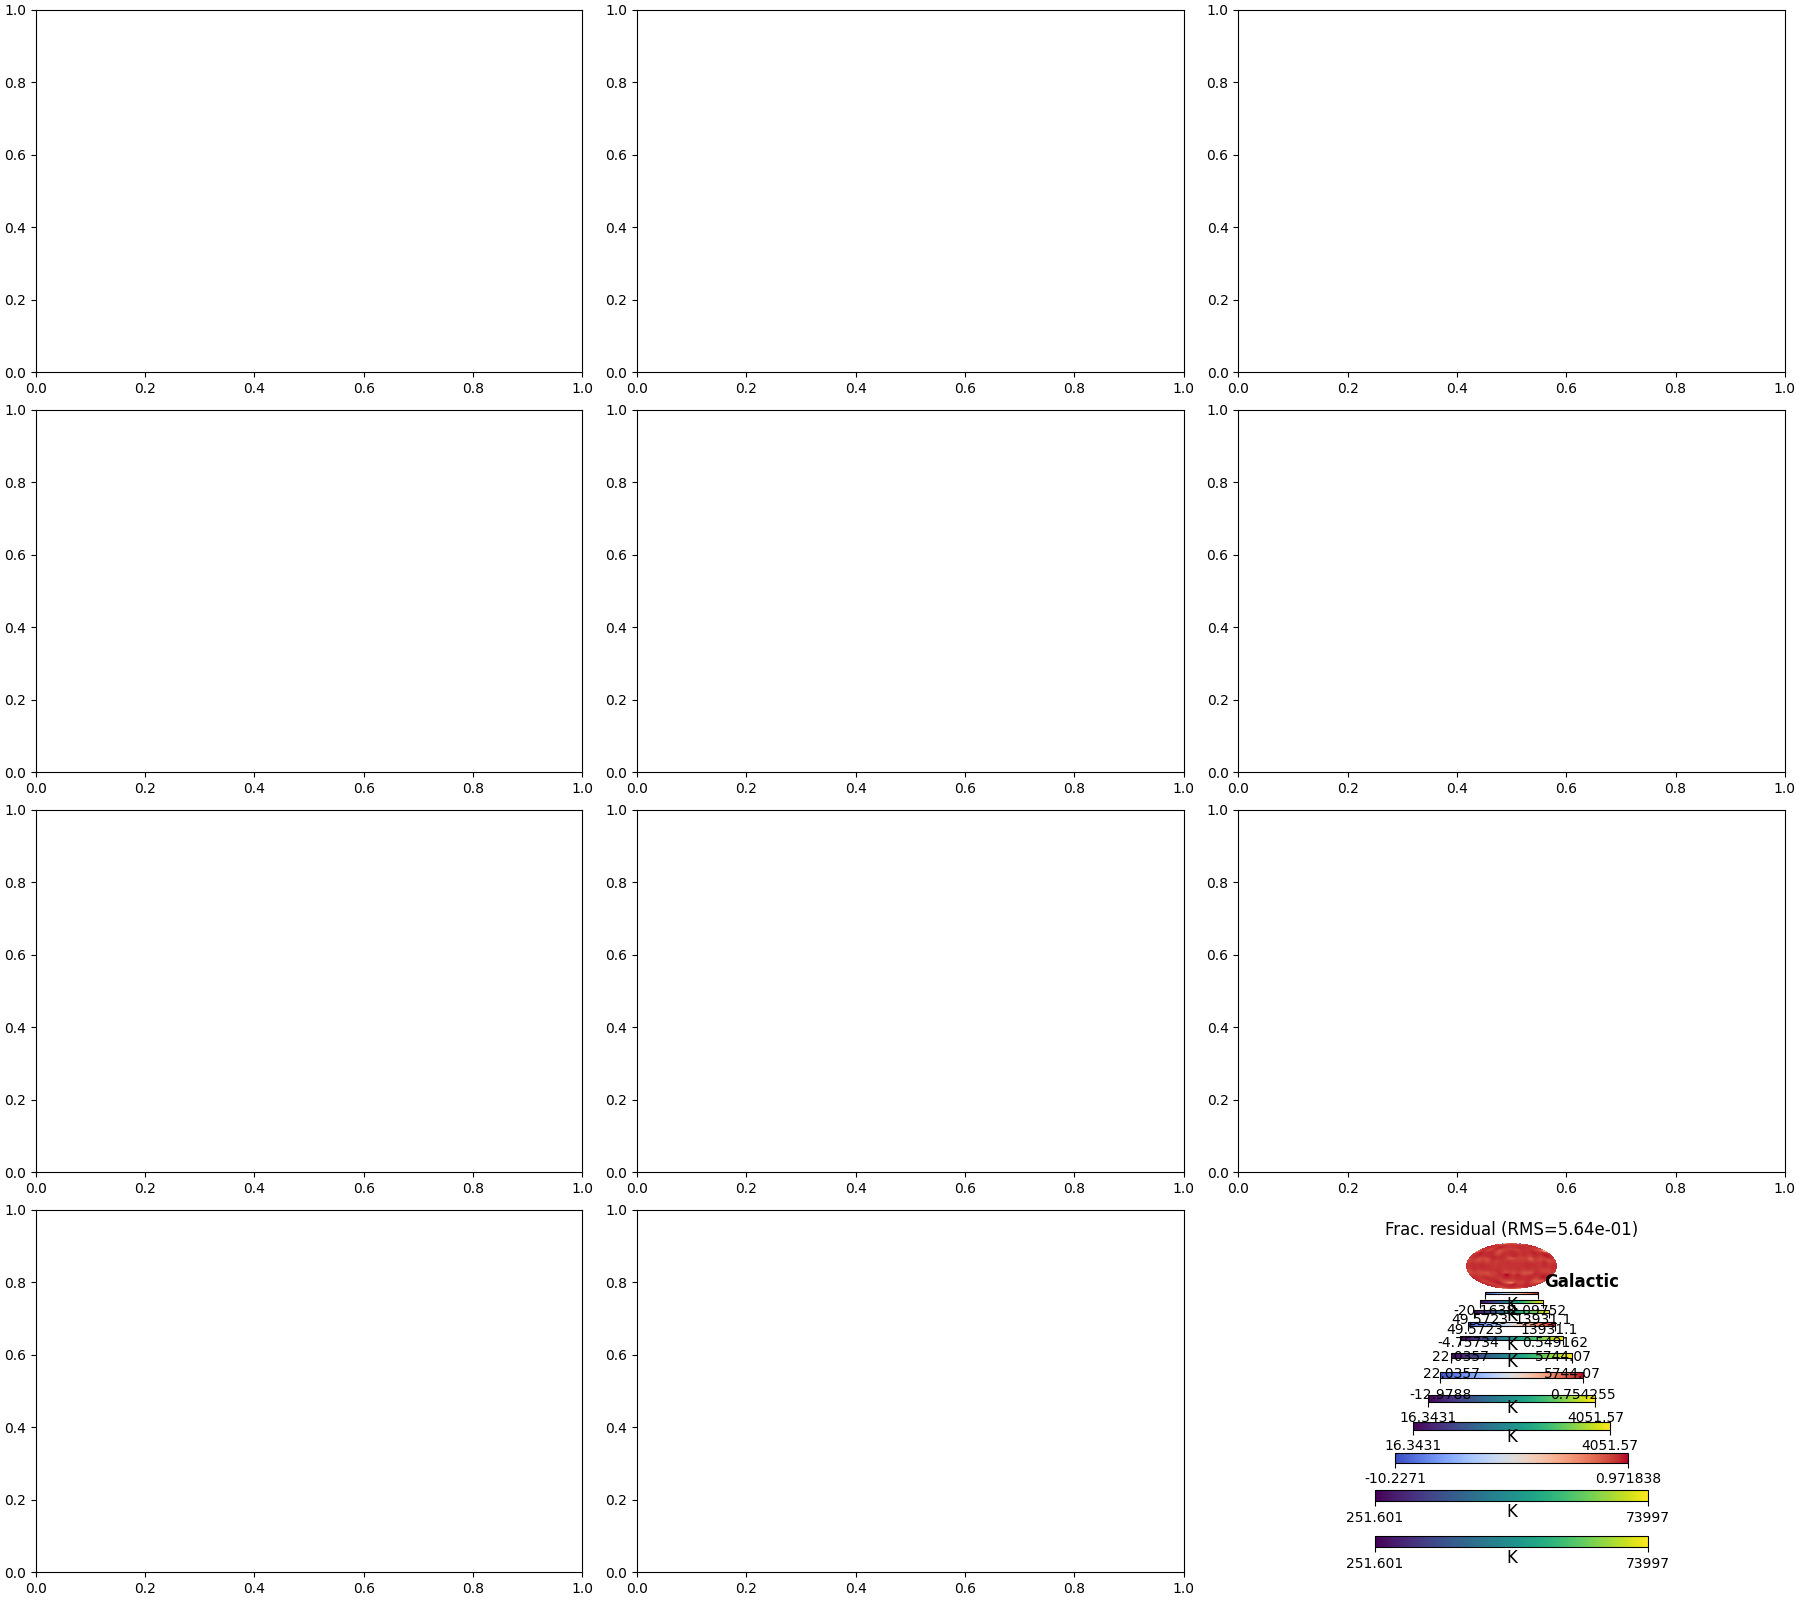

In [12]:
plot_lmax = 10
fl_plot = np.zeros(lmax + 1)
fl_plot[:plot_lmax + 1] = 1.0

n_sel = len(select)
fig, axes = plt.subplots(
    n_sel, 3, figsize=(18, 4 * n_sel),
    constrained_layout=True,
)
if n_sel == 1:
    axes = axes[np.newaxis, :]

for row, (label, fi) in enumerate(select.items()):
    true_map = hp.alm2map(
        hp.almxfl(x_true[fi], fl_plot), nside)
    rec_map = hp.alm2map(
        hp.almxfl(x_rec[fi], fl_plot), nside)
    frac_res = (true_map - rec_map) / true_map
    rms = np.std(frac_res)

    vmin, vmax = true_map.min(), true_map.max()

    for col, (m, title, kw) in enumerate([
        (true_map, f"True ({label})",
         dict(min=vmin, max=vmax, unit="K")),
        (rec_map, f"Recovered ({label})",
         dict(min=vmin, max=vmax, unit="K")),
        (frac_res, f"Frac. residual (RMS={rms:.2e})",
         dict(cmap="coolwarm")),
    ]):
        hp.mollview(
            m, title=title, coord=["C", "G"],
            hold=True,
            sub=(n_sel, 3, row * 3 + col + 1),
            fig=fig, **kw,
        )

plt.show()

## 6. Information Metrics vs Frequency

Shannon information, effective DoF, and effective rank as a
function of frequency.

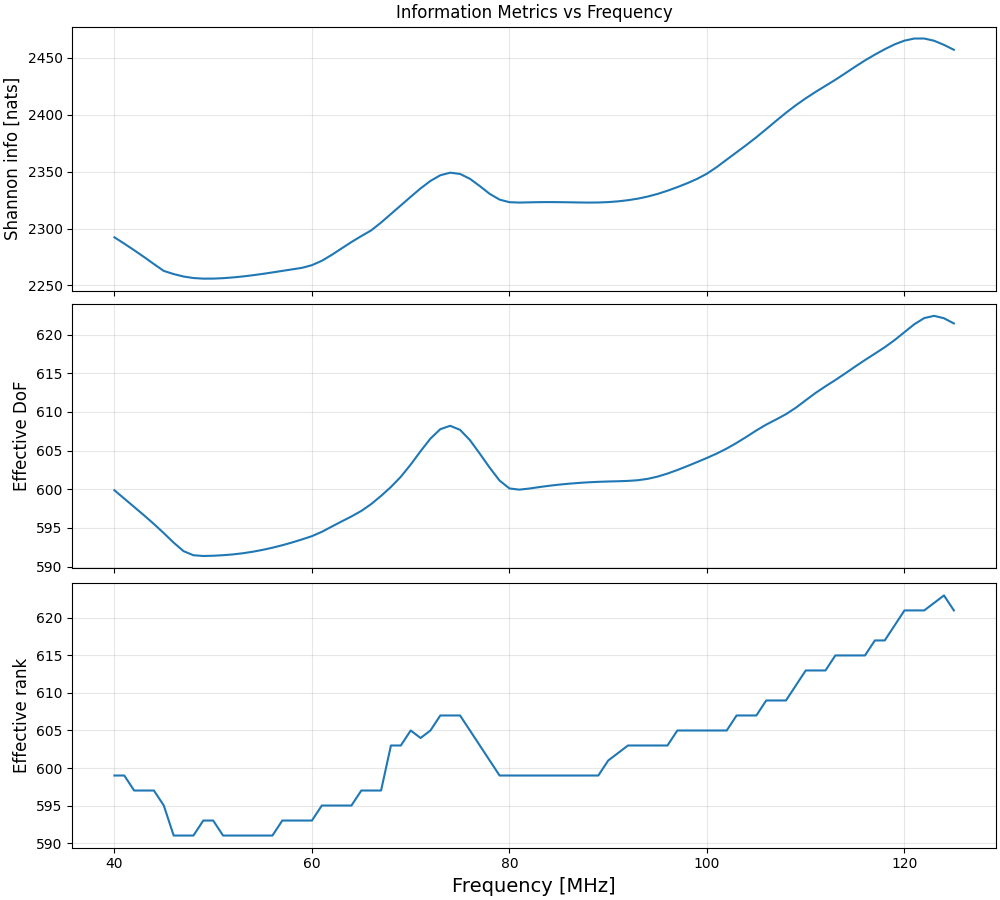

In [13]:
shannon = np.zeros(nf)
eff_dof = np.zeros(nf)
eff_rank = np.zeros(nf, dtype=int)

for fi in range(nf):
    nv = int(nvec[fi])
    s2 = Sigma[fi, :nv] ** 2
    shannon[fi] = 0.5 * np.sum(np.log(1 + s2))
    eff_dof[fi] = np.sum(s2 / (1 + s2))
    eff_rank[fi] = int(np.sum(Sigma[fi, :nv] > 1))

fig, axes = plt.subplots(3, 1, figsize=(10, 9),
                         constrained_layout=True, sharex=True)

axes[0].plot(sim_freqs, shannon, lw=1.5)
axes[0].set_ylabel("Shannon info [nats]", fontsize=12)
axes[0].set_title("Information Metrics vs Frequency")
axes[0].grid(alpha=0.3)

axes[1].plot(sim_freqs, eff_dof, lw=1.5)
axes[1].set_ylabel("Effective DoF", fontsize=12)
axes[1].grid(alpha=0.3)

axes[2].plot(sim_freqs, eff_rank, lw=1.5)
axes[2].set_xlabel("Frequency [MHz]", fontsize=14)
axes[2].set_ylabel("Effective rank", fontsize=12)
axes[2].grid(alpha=0.3)

plt.show()

## 7. Transfer Function vs Frequency

Transfer function at select multipoles ($\ell = 1, 3, 5, 10$)
as a function of frequency.

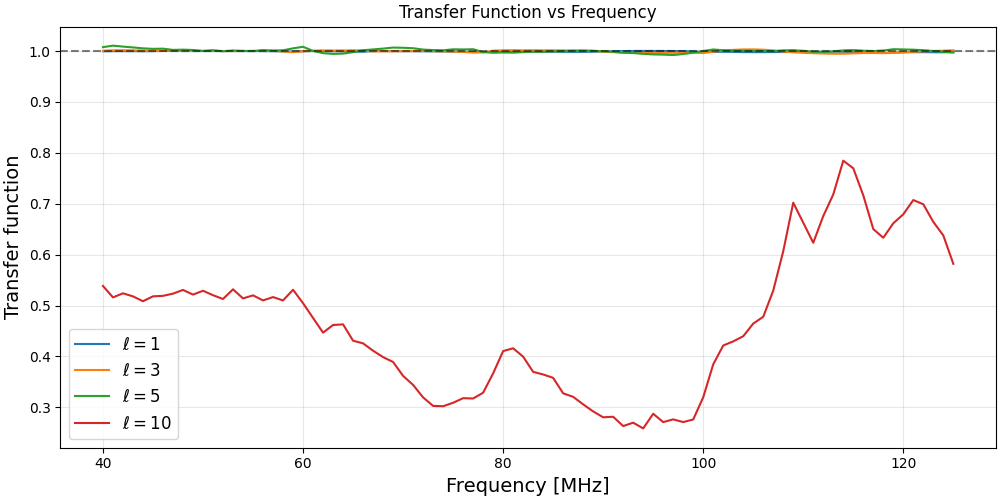

In [14]:
ell_select = [1, 3, 5, 10]

tf_vs_freq = {ell: np.zeros(nf) for ell in ell_select}

for fi in range(nf):
    cl_true_f = hp.alm2cl(x_true[fi])
    cl_cross = hp.alm2cl(x_true[fi], x_rec[fi])
    for ell in ell_select:
        if ell < len(cl_true_f) and cl_true_f[ell] > 0:
            tf_vs_freq[ell][fi] = (
                cl_cross[ell] / cl_true_f[ell]
            )

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for ell in ell_select:
    ax.plot(sim_freqs, tf_vs_freq[ell], lw=1.5,
            label=rf"$\ell = {ell}$")
ax.axhline(1, color="k", ls="--", alpha=0.5)
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Transfer function", fontsize=14)
ax.set_title("Transfer Function vs Frequency")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()